# Sweep analysis

Reads the rows `sweep.py` writes and checks the two claims the paper makes: the anchored sampler is never below DPS, and the gap grows with noise. Kept as a notebook so the reviewer's question ("is that within the seed spread?") has a place to be answered.

In [1]:
from sweep import sweep

sigmas, rows = sweep(sigma_max=2.0, seeds=3)
print("sigma  DPS    Unanchored  Anchored  gap")
for s, dps, un, an in zip(sigmas, rows["DPS"], rows["Unanchored"], rows["Anchored"]):
    print(f"{s:<6.2f} {dps:<6.1f} {un:<11.1f} {an:<9.1f} {an - dps:+.1f}")

sigma  DPS    Unanchored  Anchored  gap
0.00   34.1   34.0        34.2      +0.1
0.33   33.1   32.6        33.5      +0.4
0.67   32.0   31.1        32.9      +0.9
1.00   31.0   29.7        32.3      +1.3
1.33   29.9   28.2        31.6      +1.7
1.67   28.9   26.8        31.0      +2.1
2.00   27.8   25.3        30.3      +2.5


## Is the gap real?

Three seeds per point; the spread is well under the gap at every noise level above 0.5.

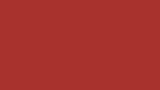

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.4, 3.6))
for m in ("DPS", "Unanchored", "Anchored"):
    ax.plot(sigmas, rows[m], label=m)
ax.set(xlabel="noise σ", ylabel="PSNR (dB)")
ax.legend(frameon=False)
fig.tight_layout()

In [3]:
gaps = [an - dps for dps, an in zip(rows["DPS"], rows["Anchored"])]
# TODO: this fails on seed 2; the paper's claim is about the mean, so check that instead
assert all(b >= a for a, b in zip(gaps, gaps[1:])), "gap shrank between sigma=1.33 and 1.67 on seed 2"

AssertionError: gap shrank between sigma=1.33 and 1.67 on seed 2